In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


# Competetion Title -- **Heavy Equipment Selling Price Prediction Challenge** (MLP Project 2026 T2)

## Name -- Soumyadip Hazari (24f3004946) (24f3004946@ds.study.iitm.ac.in)

#### Objective 

>The objective of this project is to predict the selling price of heavy equipment using classical machine learning techniques. The notebook follows a complete machine learning workflow including:

- Data understanding
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Model Training
- Hyperparameter Tuning
- Model Evaluation
- Kaggle Submission

In [2]:
# Dummy Submission
"""import pandas as pd

test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv', low_memory=False)

submission = pd.DataFrame({
    'TransactionID': test['TransactionID'],
    'TargetValue': 0
})

submission.to_csv('submission.csv', index=False)
print(f"Saved {len(submission)} rows")"""

'import pandas as pd\n\ntest = pd.read_csv(\'/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv\', low_memory=False)\n\nsubmission = pd.DataFrame({\n    \'TransactionID\': test[\'TransactionID\'],\n    \'TargetValue\': 0\n})\n\nsubmission.to_csv(\'submission.csv\', index=False)\nprint(f"Saved {len(submission)} rows")'

# Importing packages/libraries

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OrdinalEncoder
)

from sklearn.metrics import (
    root_mean_squared_log_error,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    make_scorer
)

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


import warnings
warnings.filterwarnings("ignore")

# Data Loading and Dataset Overview

In [4]:
train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")
metadata = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv")

train_cc = train.copy()
test_cc = test.copy()
sample_submission_cc = sample_submission.copy()
metadata_cc = metadata.copy()

In [5]:
print(f"Copied Train shape: {train_cc.shape}")
print(f"Train shape: {train.shape}")
print(f"Copied Test shape: {test_cc.shape}")
print(f"Test shape: {test.shape}")
print(f"Copied Metadata shape: {metadata_cc.shape}")
print(f"Metadata shape: {metadata.shape}")
print(f"Sample submission: {sample_submission_cc.shape}")

Copied Train shape: (138701, 50)
Train shape: (138701, 50)
Copied Test shape: (15000, 49)
Test shape: (15000, 49)
Copied Metadata shape: (50, 2)
Metadata shape: (50, 2)
Sample submission: (15000, 2)


In [6]:
train_cc.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


# Dataset Information

In [7]:
# train dataset inforamtion
train_cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [8]:
#Basic Data Validation
print("Target column only in training set:")
print(set(train_cc.columns) - set(test_cc.columns))

print("\nDuplicate Rows:", train_cc.duplicated().sum())

print("\nUnique Transaction IDs:", train_cc["TransactionID"].nunique())

print("Total Rows:", len(train_cc))

Target column only in training set:
{'TargetValue'}

Duplicate Rows: 0

Unique Transaction IDs: 138701
Total Rows: 138701


In [9]:
#Target Variable Analysis
train_cc["TargetValue"].describe()

count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64

In [10]:
#Missing Value Analysis
summary = pd.DataFrame({
    "Data Type": train_cc.dtypes,
    "Missing Values": train_cc.isnull().sum(),
    "Missing (%)": (
        train_cc.isnull().mean()*100
    ).round(2),
    "Unique Values": train_cc.nunique()
})

summary.sort_values(
    "Missing (%)",
    ascending=False
)

,Data Type,Missing Values,Missing (%),Unique Values
col19,object,138635,99.95,2
col18,object,138635,99.95,2
col5,object,128320,92.52,2
col4,object,128320,92.52,2
col27,object,123742,89.21,9
col28,object,123742,89.21,5
col29,object,119829,86.39,3
col30,object,119829,86.39,2
col13,object,115296,83.13,2
col14,object,115296,83.13,3


In [11]:
#Categorical Cardinality
train_cc.select_dtypes(include="object").nunique().sort_values(ascending=False)

TransactionDate              3676
Spec_FullDescriptor          3505
Spec_BaseClass               1249
Spec_SubClass                 147
Spec_VariantModifier          132
Spec_ReleaseSeries            113
FunctionalClassification       65
RegionCode                     53
VendorPartnerID                31
col22                          27
col21                          18
col15                          15
col10                          11
col27                           9
DrivetrainType                  8
DataOriginCode                  6
col7                            6
AssetScaleFactor                6
InventoryGroupDescription       6
InventoryGroupCategory          6
col28                           5
col1                            4
col12                           4
UtilizationTier                 3
col3                            3
col8                            3
col23                           3
CabinType                       3
col25                           3
col24         

# Exploratory Data Analysis (EDA)

### Target Variable Analysis

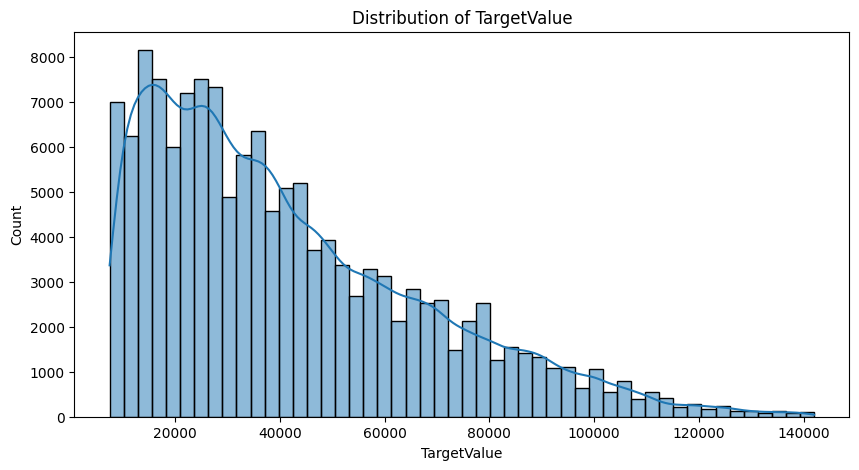

In [12]:
train_cc["TargetValue"].describe()

plt.figure(figsize=(10,5))

sns.histplot(
    train_cc["TargetValue"],
    bins=50,
    kde=True
)

plt.title("Distribution of TargetValue")
plt.show()

### Numerical Feature Analysis

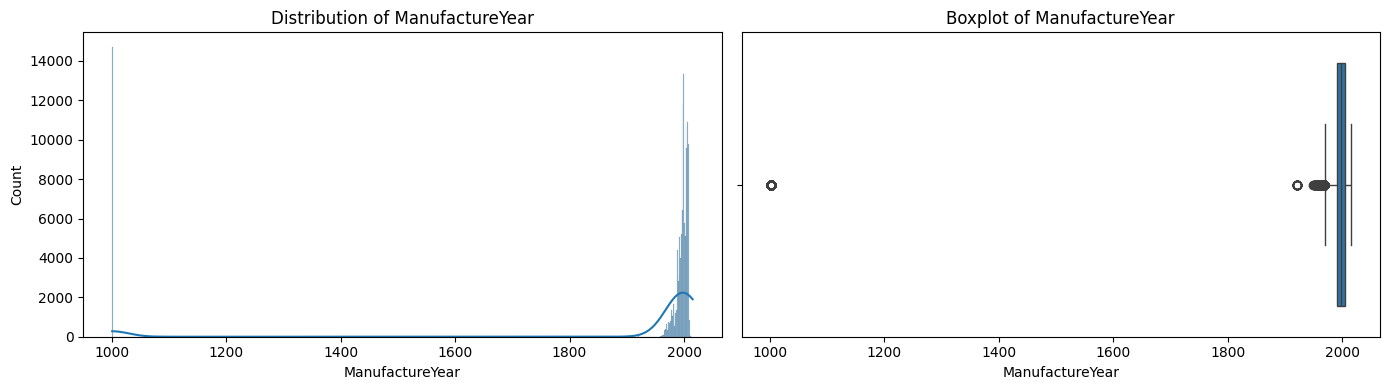

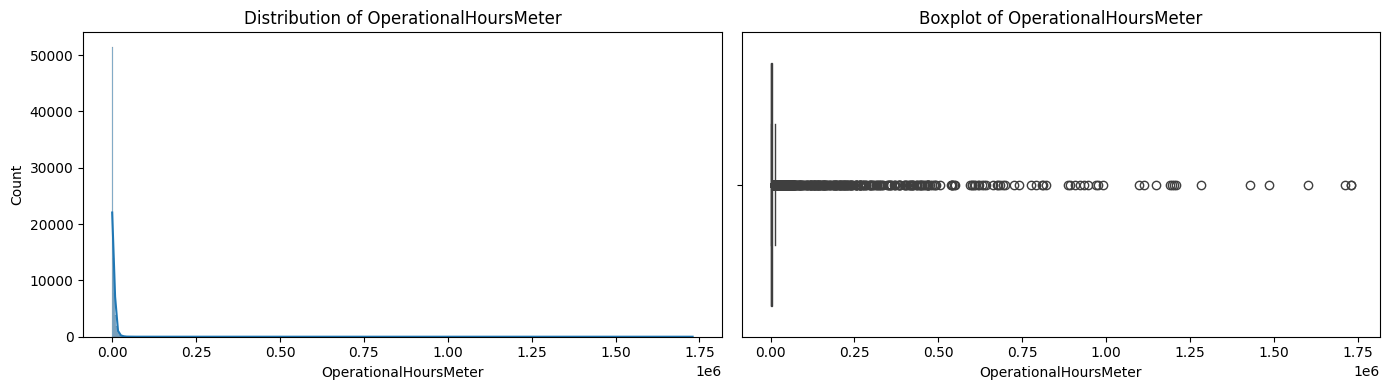

In [13]:
numerical_cols = [
    "ManufactureYear",
    "OperationalHoursMeter"
]
for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(train_cc[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")

    sns.boxplot(x=train_cc[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

### Relationship With Target

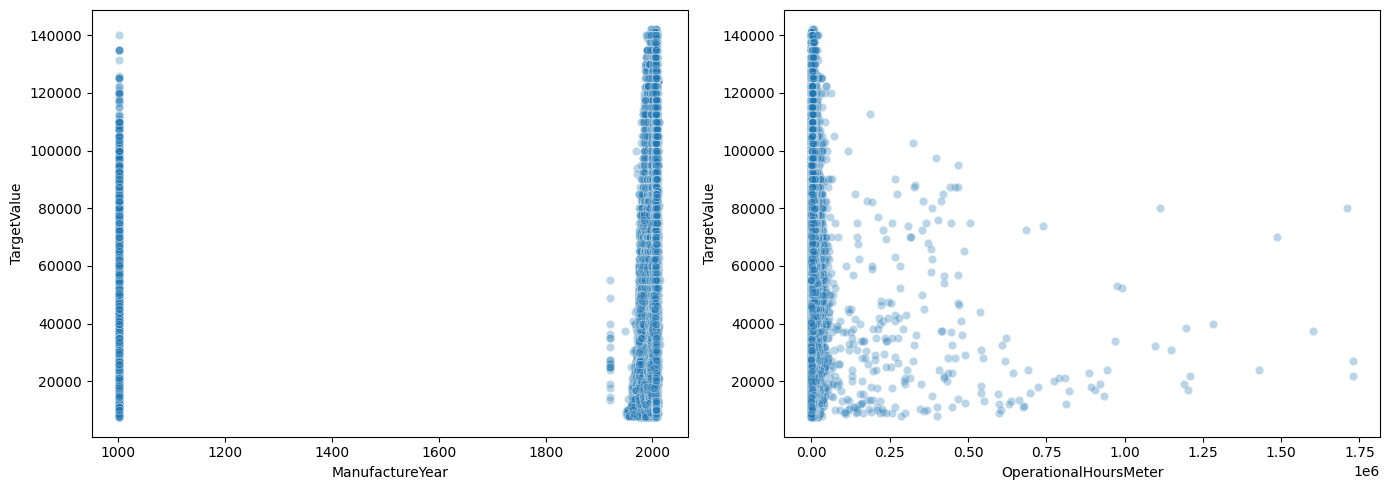

In [14]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.scatterplot(
    data=train_cc,
    x="ManufactureYear",
    y="TargetValue",
    alpha=0.3,
    ax=axes[0]
)

sns.scatterplot(
    data=train_cc,
    x="OperationalHoursMeter",
    y="TargetValue",
    alpha=0.3,
    ax=axes[1]
)

plt.tight_layout()
plt.show()

### Transaction Data Analysis

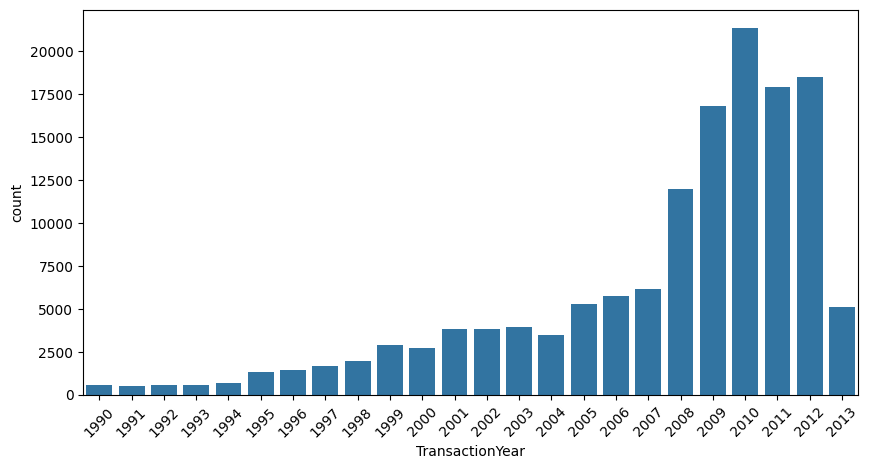

In [15]:
train_cc["TransactionDate"] = pd.to_datetime(train_cc["TransactionDate"])
train_cc["TransactionYear"] = train_cc["TransactionDate"].dt.year
train_cc["TransactionMonth"] = train_cc["TransactionDate"].dt.month
plt.figure(figsize=(10,5))

sns.countplot(
    x="TransactionYear",
    data=train_cc,
    order=sorted(train_cc["TransactionYear"].unique())
)

plt.xticks(rotation=45)
plt.show()

### Categorical Features

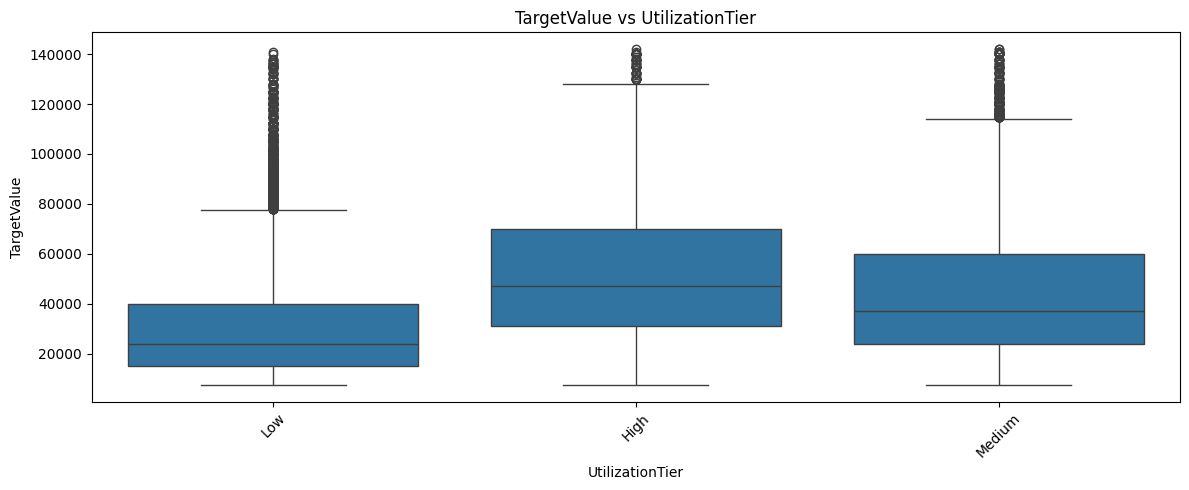

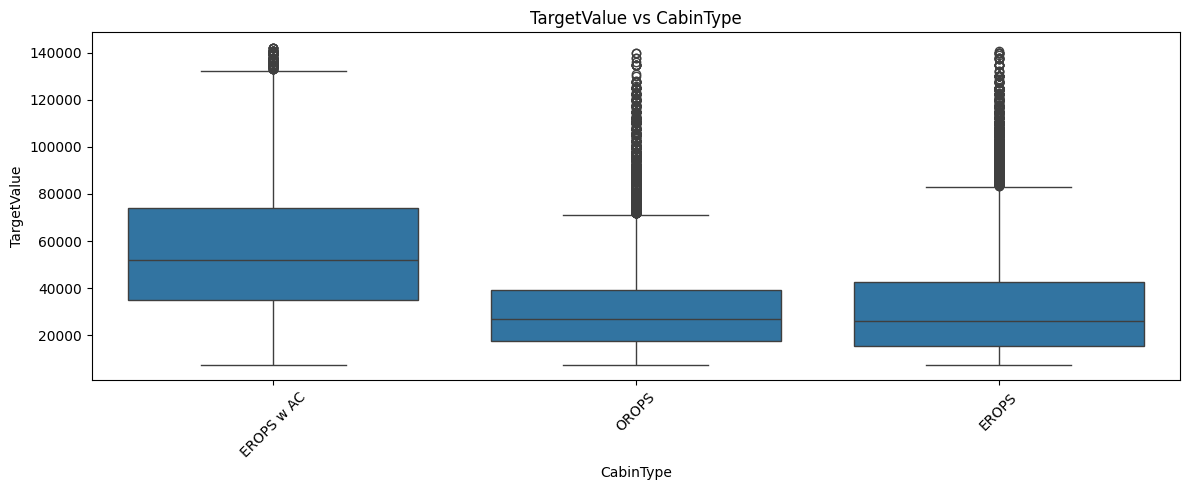

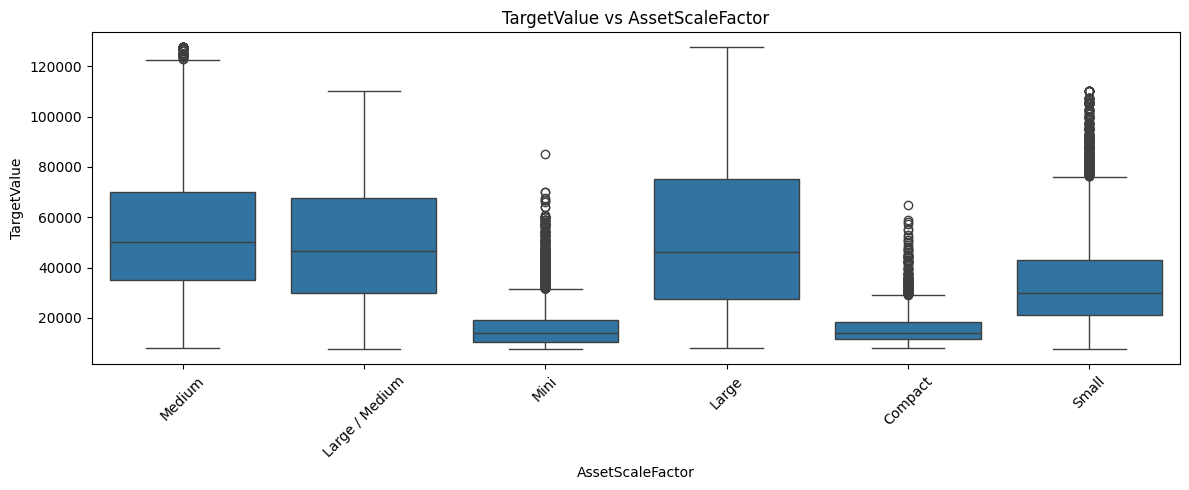

In [16]:
important_cat = [
    "UtilizationTier",
    "CabinType",
    "AssetScaleFactor"
]
for column in important_cat:
    plt.figure(figsize=(12, 5))

    sns.boxplot(
        data=train_cc,
        x=column,
        y="TargetValue"
    )

    plt.title(f"TargetValue vs {column}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### Missing Value Visualization

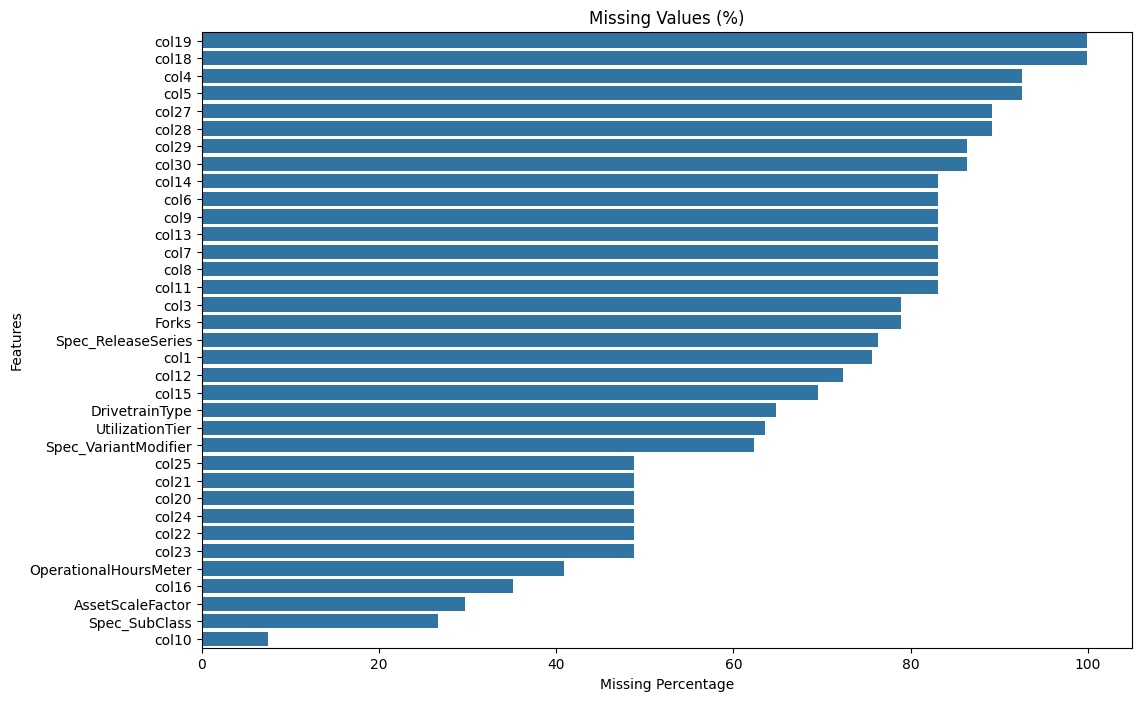

In [17]:
missing_percent = (
    train_cc.isnull().mean()*100
).sort_values(ascending=False)

missing_percent = missing_percent[missing_percent>0]

plt.figure(figsize=(12,8))

sns.barplot(
    x=missing_percent.values,
    y=missing_percent.index
)

plt.xlabel("Missing Percentage")
plt.ylabel("Features")
plt.title("Missing Values (%)")
plt.show()

### MachineAge Analysis

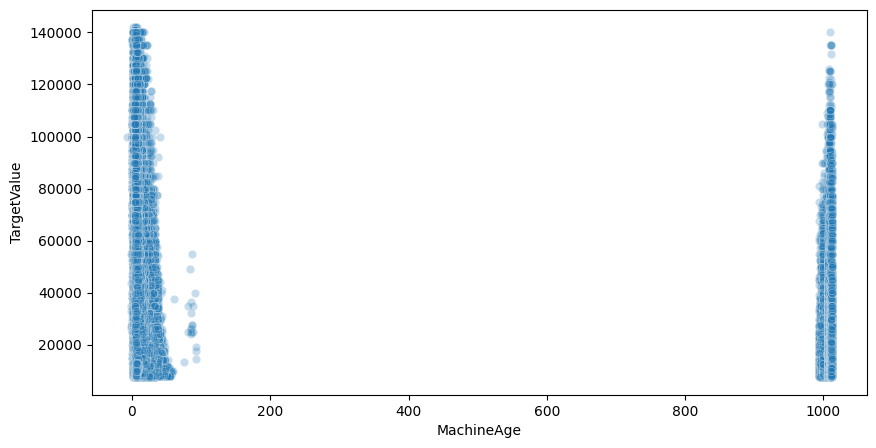

In [18]:
train_cc["MachineAge"] = (train_cc["TransactionYear"]- train_cc["ManufactureYear"])
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=train_cc,
    x="MachineAge",
    y="TargetValue",
    alpha=0.25
)

plt.show()

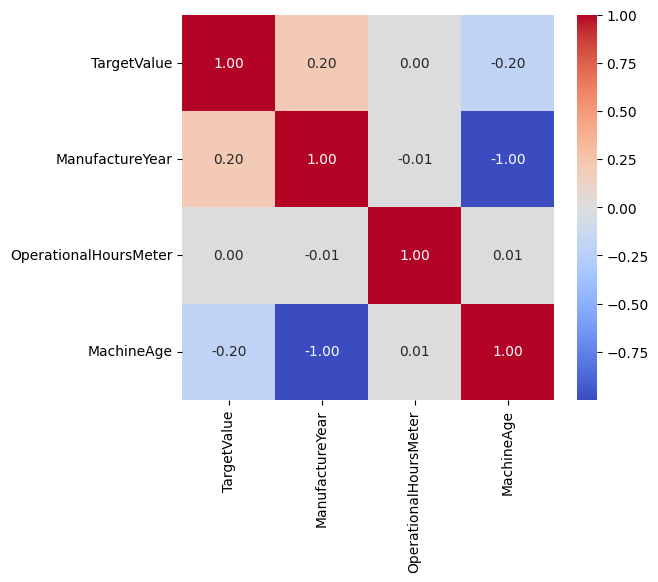

In [19]:
corr = train_cc[
[
"TargetValue",
"ManufactureYear",
"OperationalHoursMeter",
"MachineAge"
]
].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

# Data Cleaning and Feature Engeineering

## Invalid ManufactureYear

In [20]:
train_cc["ManufactureYear"].describe()

print("Minimum Year:", train_cc["ManufactureYear"].min())
print("Maximum Year:", train_cc["ManufactureYear"].max())

Minimum Year: 1001
Maximum Year: 2015


In [21]:
invalid_count = (train_cc["ManufactureYear"] < 1900).sum()

print(f"Invalid rows: {invalid_count}")
print(f"Percentage : {invalid_count / len(train_cc) * 100:.2f}%")

Invalid rows: 14719
Percentage : 10.61%


In [22]:
def create_features(df):

    df = df.copy()

    # Manufacture Year
    df["ManufactureYearMissing"] = (
        df["ManufactureYear"] == 1001
    ).astype(int)

    df["ManufactureYear"] = (
        df["ManufactureYear"]
        .replace(1001, np.nan)
    )

    # Date Features
    df["TransactionDate"] = pd.to_datetime(
        df["TransactionDate"]
    )

    df["TransactionYear"] = (
        df["TransactionDate"].dt.year
    )

    df["TransactionMonth"] = (
        df["TransactionDate"].dt.month
    )

    df["TransactionQuarter"] = (
        df["TransactionDate"].dt.quarter
    )

    df["TransactionWeekday"] = (
        df["TransactionDate"].dt.dayofweek
    )

    # Machine Age
    df["MachineAge"] = (
        df["TransactionYear"]
        -
        df["ManufactureYear"]
    )

    # Usage Rate
    df["HoursPerYear"] = (
        df["OperationalHoursMeter"]
        /
        (df["MachineAge"] + 1)
    )

    # Manufacture Decade
    df["ManufactureDecade"] = (
        df["ManufactureYear"] // 10
    ) * 10

    # Machine Age Group
    df["MachineAgeGroup"] = pd.cut(
        df["MachineAge"],
        bins=[0,5,10,20,30,50,np.inf],
        labels=[
            "0-5",
            "6-10",
            "11-20",
            "21-30",
            "31-50",
            "50+"
        ]
    )

    return df

In [23]:
train_cc = create_features(train_cc)
print(f"New copied train Shape: {train_cc.shape}")
print(f"Old train Shape: {train.shape}")
print(f"New Features Added : "f"{train_cc.shape[1] - train.shape[1]}")

New copied train Shape: (138701, 59)
Old train Shape: (138701, 50)
New Features Added : 9


### HoursPerYear vs Target

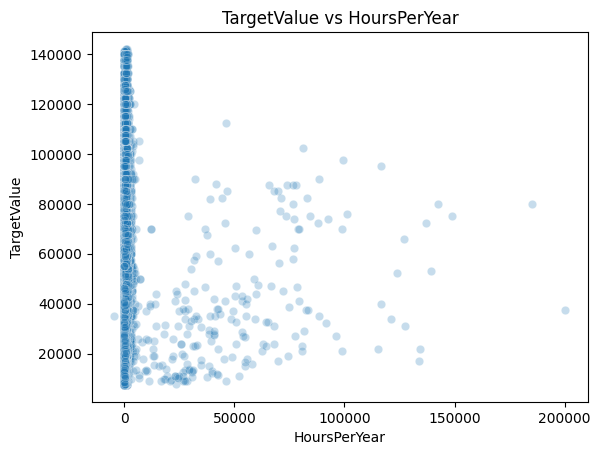

In [24]:
sns.scatterplot(
    data=train_cc,
    x="HoursPerYear",
    y="TargetValue",
    alpha=0.25
)

plt.title("TargetValue vs HoursPerYear")
plt.show()

### ManufactureDecade vs Target

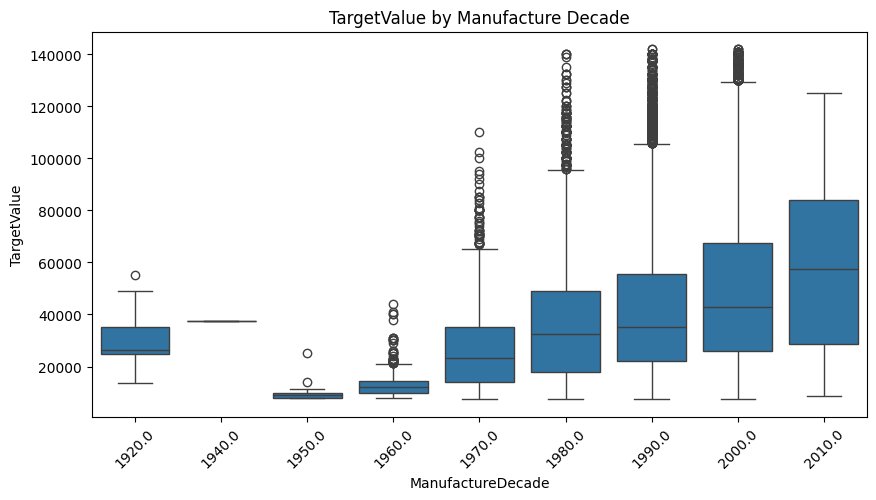

In [25]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=train_cc,
    x="ManufactureDecade",
    y="TargetValue"
)

plt.xticks(rotation=45)
plt.title("TargetValue by Manufacture Decade")
plt.show()

# Train-Validation Split

In [26]:
target = "TargetValue"

drop_columns = ["TransactionID","TransactionDate"]
x = train_cc.drop(columns=drop_columns + [target])
# TransactionID is a unique identifier.
# TransactionDate has already been decomposed into useful date-based features.
y = train_cc[target]

print(f"Feature Matrix Shape : {x.shape}")
print(f"Target Shape         : {y.shape}")

Feature Matrix Shape : (138701, 56)
Target Shape         : (138701,)


In [27]:
# Train-Validation Split
x_train, x_valid, y_train, y_valid = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Training Features   : {x_train.shape}")
print(f"Validation Features : {x_valid.shape}")

print(f"Training Target     : {y_train.shape}")
print(f"Validation Target   : {y_valid.shape}")

Training Features   : (110960, 56)
Validation Features : (27741, 56)
Training Target     : (110960,)
Validation Target   : (27741,)


In [28]:
numerical_features = x_train.select_dtypes(
    include="number"
).columns.tolist()

categorical_features = x_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features   : 12
Categorical Features : 44

Numerical Features:
['AssetID', 'ProductConfigID', 'ManufactureYear', 'OperationalHoursMeter', 'TransactionYear', 'TransactionMonth', 'MachineAge', 'ManufactureYearMissing', 'TransactionQuarter', 'TransactionWeekday', 'HoursPerYear', 'ManufactureDecade']

Categorical Features:
['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30', 'MachineAgeGroup']


In [29]:
print(f"Total Features : {x_train.shape[1]}")
print(f"Numerical      : {len(numerical_features)}")
print(f"Categorical    : {len(categorical_features)}")

Total Features : 56
Numerical      : 12
Categorical    : 44


# Preprocessing Pipeline
> The preprocessing pipeline is fitted only on the training data. During prediction, the same fitted pipeline automatically transforms the test dataset using transform() inside the model pipeline.
- It ensures identical preprocessing without data leakage

In [30]:
# Numerical preprocessing
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

# Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

x_train_processed = preprocessor.fit_transform(
    x_train
)

x_valid_processed = preprocessor.transform(
    x_valid
)

print(f"Processed Training Shape   : {x_train_processed.shape}")
print(f"Processed Validation Shape : {x_valid_processed.shape}")

Processed Training Shape   : (110960, 56)
Processed Validation Shape : (27741, 56)


# Baseline Models 

## Random Forest Regressor (Model 1)

In [31]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline.fit(
    x_train,
    y_train
)

y_pred = rf_pipeline.predict(
    x_valid
)

In [32]:
rmsle = root_mean_squared_log_error(
    y_valid,
    y_pred
)

mae = mean_absolute_error(
    y_valid,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        y_pred
    )
)

r2 = r2_score(
    y_valid,
    y_pred
)

print(f"Validation RMSLE : {rmsle:.5f}")
print(f"Validation MAE   : {mae:.2f}")
print(f"Validation RMSE  : {rmse:.2f}")
print(f"Validation R²    : {r2:.4f}")

Validation RMSLE : 0.23115
Validation MAE   : 5984.13
Validation RMSE  : 8896.65
Validation R²    : 0.8845


In [33]:
# Important features

feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(len(rf_pipeline.named_steps["model"].feature_importances_))

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_pipeline.named_steps[
        "model"
    ].feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance.head(20)

56
56


,Feature,Importance
20,cat__AssetScaleFactor,0.188837
6,num__MachineAge,0.163365
21,cat__FunctionalClassification,0.113317
1,num__ProductConfigID,0.069110
0,num__AssetID,0.053222
16,cat__Spec_BaseClass,0.052738
2,num__ManufactureYear,0.050447
17,cat__Spec_SubClass,0.049056
38,cat__col12,0.043567
15,cat__Spec_FullDescriptor,0.034294


In [34]:
feature_importance[
    feature_importance["Feature"].str.contains(
        "Machine|Hours|Transaction|Manufacture",
        case=False
    )
]

,Feature,Importance
6,num__MachineAge,0.163365
2,num__ManufactureYear,0.050447
4,num__TransactionYear,0.028350
5,num__TransactionMonth,0.013368
9,num__TransactionWeekday,0.007883
3,num__OperationalHoursMeter,0.006830
10,num__HoursPerYear,0.005488
11,num__ManufactureDecade,0.004231
8,num__TransactionQuarter,0.003283
7,num__ManufactureYearMissing,0.003118


## LightGBM Baseline (Model 2)

In [35]:
lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LGBMRegressor(
                n_estimators=300,
                learning_rate=0.05,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

lgbm_pipeline.fit(
    x_train,
    y_train
)

lgbm_pred = lgbm_pipeline.predict(
    x_valid
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017937 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2329
[LightGBM] [Info] Number of data points in the train set: 110960, number of used features: 54
[LightGBM] [Info] Start training from score 41559.253875


In [36]:
lgbm_rmsle = root_mean_squared_log_error(
    y_valid,
    lgbm_pred
)

lgbm_mae = mean_absolute_error(
    y_valid,
    lgbm_pred
)

lgbm_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        lgbm_pred
    )
)

lgbm_r2 = r2_score(
    y_valid,
    lgbm_pred
)

print(f"Validation RMSLE : {lgbm_rmsle:.5f}")
print(f"Validation MAE   : {lgbm_mae:.2f}")
print(f"Validation RMSE  : {lgbm_rmse:.2f}")
print(f"Validation R²    : {lgbm_r2:.4f}")

Validation RMSLE : 0.26116
Validation MAE   : 6762.55
Validation RMSE  : 9531.32
Validation R²    : 0.8674


## Catboost Baseline (Model 3)

In [37]:
x_train_cb = x_train.copy()
x_valid_cb = x_valid.copy()

categorical_columns = x_train_cb.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Categorical Features : {len(categorical_columns)}")

Categorical Features : 44


In [38]:
for col in categorical_columns:

    x_train_cb[col] = x_train_cb[col].astype(str)
    x_valid_cb[col] = x_valid_cb[col].astype(str)

for col in categorical_columns:
    x_train_cb[col] = x_train_cb[col].fillna("Missing")
    x_valid_cb[col] = x_valid_cb[col].fillna("Missing")

numeric_columns = x_train_cb.select_dtypes(
    include="number"
).columns.tolist()

for col in numeric_columns:
    median_value = x_train_cb[col].median()

    x_train_cb[col] = x_train_cb[col].fillna(median_value)
    x_valid_cb[col] = x_valid_cb[col].fillna(median_value)

In [39]:
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100,
    allow_writing_files=False,
    task_type="GPU"
)

cat_model.fit(
    x_train_cb,
    y_train,
    cat_features=categorical_columns
)

cat_pred = cat_model.predict(
    x_valid_cb
)

0:	learn: 25520.1807524	total: 130ms	remaining: 1m 4s
100:	learn: 10699.4538716	total: 5.06s	remaining: 20s
200:	learn: 9820.8112812	total: 9.58s	remaining: 14.3s
300:	learn: 9360.0364586	total: 14.1s	remaining: 9.35s
400:	learn: 9090.8919757	total: 18.7s	remaining: 4.61s
499:	learn: 8886.3447835	total: 23.1s	remaining: 0us


In [40]:
cat_rmsle = root_mean_squared_log_error(
    y_valid,
    cat_pred
)

cat_mae = mean_absolute_error(
    y_valid,
    cat_pred
)

cat_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        cat_pred
    )
)

cat_r2 = r2_score(
    y_valid,
    cat_pred
)

print(f"Validation RMSLE : {cat_rmsle:.5f}")
print(f"Validation MAE   : {cat_mae:.2f}")
print(f"Validation RMSE  : {cat_rmse:.2f}")
print(f"Validation R²    : {cat_r2:.4f}")

Validation RMSLE : 0.23547
Validation MAE   : 6247.37
Validation RMSE  : 8856.91
Validation R²    : 0.8855


## XGBoost Baseline (Model 4)

In [41]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                n_estimators=300,
                learning_rate=0.05,
                max_depth=8,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_pipeline.fit(
    x_train,
    y_train
)

xgb_pred = xgb_pipeline.predict(
    x_valid
)

xgb_rmsle = root_mean_squared_log_error(
    y_valid,
    xgb_pred
)

xgb_mae = mean_absolute_error(
    y_valid,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    y_valid,
    xgb_pred
)

print(f"Validation RMSLE : {xgb_rmsle:.5f}")
print(f"Validation MAE   : {xgb_mae:.2f}")
print(f"Validation RMSE  : {xgb_rmse:.2f}")
print(f"Validation R²    : {xgb_r2:.4f}")

Validation RMSLE : 0.23624
Validation MAE   : 6120.76
Validation RMSE  : 8798.79
Validation R²    : 0.8870


## Comparison Table and plot between Baseline Models

In [42]:
baseline_results = pd.DataFrame({

    "Model":["Random Forest","LightGBM","CatBoost","XGBoost"],

    "RMSLE":[rmsle,lgbm_rmsle,cat_rmsle,xgb_rmsle],

    "MAE":[mae,lgbm_mae,cat_mae,xgb_mae],

    "RMSE":[rmse,lgbm_rmse,cat_rmse,xgb_rmse],

    "R²":[r2,lgbm_r2,cat_r2,xgb_r2]

})

baseline_results.sort_values("RMSLE")

,Model,RMSLE,MAE,RMSE,R²
0,Random Forest,0.231145,5984.125746,8896.653413,0.884496
2,CatBoost,0.235468,6247.366096,8856.914601,0.885525
3,XGBoost,0.236243,6120.757558,8798.785402,0.887023
1,LightGBM,0.261165,6762.545568,9531.315890,0.867428


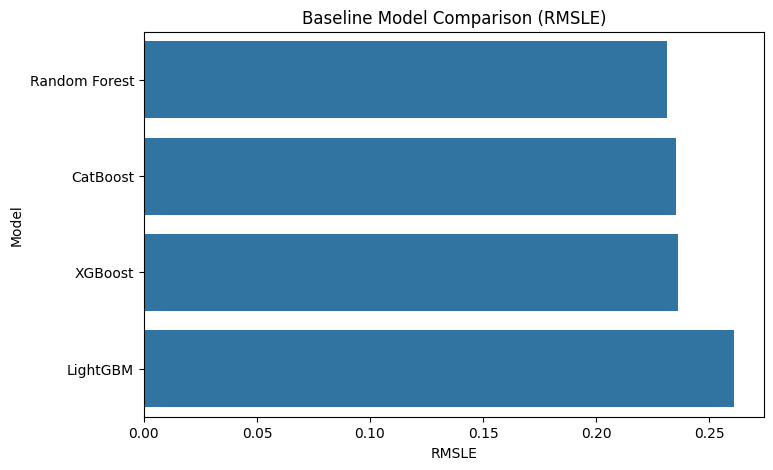

In [43]:
# Visualizer
plt.figure(figsize=(8,5))

sns.barplot(
    data=baseline_results.sort_values("RMSLE"),
    x="RMSLE",
    y="Model"
)

plt.title("Baseline Model Comparison (RMSLE)")
plt.show()

Observation --

>Among the baseline models, XGBoost achieved the lowest RMSLE, followed closely by Random Forest and CatBoost. LightGBM performed comparatively worse with its default parameters. Based on these observations, gradient boosting models were selected for further optimization using log-transformed targets and hyperparameter tuning.

# Log Transformation

In [44]:
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

print(y_train.head())
print(y_train_log.head())

35835    21000.0
33687    56000.0
46296    10000.0
26487    28500.0
71601    64000.0
Name: TargetValue, dtype: float64
35835     9.952325
33687    10.933125
46296     9.210440
26487    10.257694
71601    11.066654
Name: TargetValue, dtype: float64


# Baseline Models Logged version
## Random Forest Logged version

In [45]:
rf_log_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_log_pipeline.fit(
    x_train,
    y_train_log
)

rf_log_pred = rf_log_pipeline.predict(
    x_valid
)

rf_pred_original = np.expm1(
    rf_log_pred
)

In [46]:
rf_log_rmsle = root_mean_squared_log_error(
    y_valid,
    rf_pred_original
)

rf_log_mae = mean_absolute_error(
    y_valid,
    rf_pred_original
)

rf_log_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        rf_pred_original
    )
)

rf_log_r2 = r2_score(
    y_valid,
    rf_pred_original
)

print(f"Validation RMSLE : {rf_log_rmsle:.5f}")
print(f"Validation MAE   : {rf_log_mae:.2f}")
print(f"Validation RMSE  : {rf_log_rmse:.2f}")
print(f"Validation R²    : {rf_log_r2:.4f}")

Validation RMSLE : 0.22582
Validation MAE   : 5954.39
Validation RMSE  : 9103.94
Validation R²    : 0.8791


## Catboost Logged version

In [47]:
cat_log_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=200,
    allow_writing_files=False,
    task_type="GPU"
)

cat_log_model.fit(
    x_train_cb,
    y_train_log,
    cat_features=categorical_columns
)

cat_log_pred = cat_log_model.predict(
    x_valid_cb
)

cat_pred_original = np.expm1(
    cat_log_pred
)

0:	learn: 0.6568945	total: 65.4ms	remaining: 1m 5s
200:	learn: 0.2596253	total: 9.58s	remaining: 38.1s
400:	learn: 0.2416913	total: 18.7s	remaining: 28s
600:	learn: 0.2317516	total: 27.9s	remaining: 18.5s
800:	learn: 0.2256026	total: 37.3s	remaining: 9.26s
999:	learn: 0.2212108	total: 46.8s	remaining: 0us


In [48]:
cat_log_rmsle = root_mean_squared_log_error(
    y_valid,
    cat_pred_original
)

cat_log_mae = mean_absolute_error(
    y_valid,
    cat_pred_original
)

cat_log_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        cat_pred_original
    )
)

cat_log_r2 = r2_score(
    y_valid,
    cat_pred_original
)

print(f"Validation RMSLE : {cat_log_rmsle:.5f}")
print(f"Validation MAE   : {cat_log_mae:.2f}")
print(f"Validation RMSE  : {cat_log_rmse:.2f}")
print(f"Validation R²    : {cat_log_r2:.4f}")

Validation RMSLE : 0.22102
Validation MAE   : 6108.30
Validation RMSE  : 8919.15
Validation R²    : 0.8839


# XGboost Logged Version

In [49]:
xgb_log_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=8,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                tree_method="hist",
                device="cuda"
            )
        )
    ]
)

xgb_log_pipeline.fit(
    x_train,
    y_train_log
)

xgb_log_pred = xgb_log_pipeline.predict(
    x_valid
)

xgb_pred_original = np.expm1(
    xgb_log_pred
)

In [50]:
xgb_log_rmsle = root_mean_squared_log_error(
    y_valid,
    xgb_pred_original
)

xgb_log_mae = mean_absolute_error(
    y_valid,
    xgb_pred_original
)

xgb_log_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        xgb_pred_original
    )
)

xgb_log_r2 = r2_score(
    y_valid,
    xgb_pred_original
)

print(f"Validation RMSLE : {xgb_log_rmsle:.5f}")
print(f"Validation MAE   : {xgb_log_mae:.2f}")
print(f"Validation RMSE  : {xgb_log_rmse:.2f}")
print(f"Validation R²    : {xgb_log_r2:.4f}")

Validation RMSLE : 0.21392
Validation MAE   : 5762.26
Validation RMSE  : 8580.13
Validation R²    : 0.8926


## LightGBM logged version

In [51]:
lgbm_log_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LGBMRegressor(
                n_estimators=500,
                learning_rate=0.05,
                num_leaves=63,
                feature_fraction=0.8,
                bagging_fraction=0.8,
                bagging_freq=1,
                random_state=42,
                device="gpu",
                verbose=-1
            )
        )
    ]
)

lgbm_log_pipeline.fit(
    x_train,
    y_train_log
)
lgbm_log_pred = lgbm_log_pipeline.predict(
    x_valid
)

lgbm_pred = np.expm1(
    lgbm_log_pred
)

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


In [52]:
lgbm_rmsle = root_mean_squared_log_error(
    y_valid,
    lgbm_pred
)

lgbm_mae = mean_absolute_error(
    y_valid,
    lgbm_pred
)

lgbm_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        lgbm_pred
    )
)

lgbm_r2 = r2_score(
    y_valid,
    lgbm_pred
)

print(f"Validation RMSLE : {lgbm_rmsle:.5f}")
print(f"Validation MAE   : {lgbm_mae:.2f}")
print(f"Validation RMSE  : {lgbm_rmse:.2f}")
print(f"Validation R²    : {lgbm_r2:.4f}")

Validation RMSLE : 0.21962
Validation MAE   : 5968.33
Validation RMSE  : 8825.32
Validation R²    : 0.8863


## Comparison table and plot for the logged version 

In [53]:
logged_results = pd.DataFrame({

    "Model":["Random Forest (Log)","CatBoost (Log)","XGBoost (Log)","LightGBM (Log)"],

    "RMSLE":[rf_log_rmsle,cat_log_rmsle,xgb_log_rmsle,lgbm_rmsle],

    "MAE":[rf_log_mae,cat_log_mae,xgb_log_mae,lgbm_mae],

    "RMSE":[rf_log_rmse,cat_log_rmse,xgb_log_rmse,lgbm_rmse],

    "R²":[rf_log_r2,cat_log_r2,xgb_log_r2,lgbm_r2]
})

logged_results.sort_values("RMSLE")

,Model,RMSLE,MAE,RMSE,R²
2,XGBoost (Log),0.213925,5762.256435,8580.129685,0.892568
3,LightGBM (Log),0.219624,5968.330099,8825.318451,0.886341
1,CatBoost (Log),0.221021,6108.303250,8919.149338,0.883911
0,Random Forest (Log),0.225822,5954.387462,9103.939358,0.879051


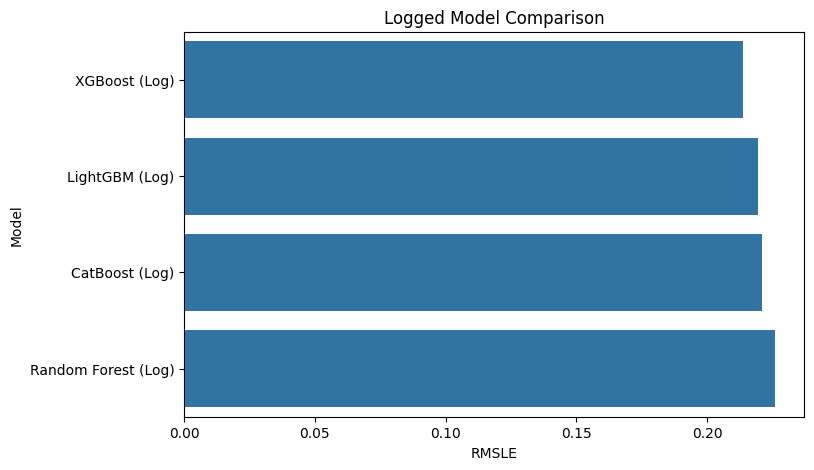

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=logged_results.sort_values("RMSLE"),
    x="RMSLE",
    y="Model"
)

plt.title("Logged Model Comparison")
plt.show()

# Custom scorer

In [55]:
from sklearn.metrics import make_scorer

def rmsle_score(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    y_true = np.maximum(y_true, 0)
    return root_mean_squared_log_error(y_true, y_pred)

rmsle_scorer = make_scorer(
    rmsle_score,
    greater_is_better=False
)

# Hyper Parameter Tuning

## For the XGBoost Model 

In [56]:
xgb_param_dist = {
    "model__n_estimators": [400, 500, 700, 900],
    "model__max_depth": [5, 6, 8, 10],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__subsample": [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 0.9],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.3]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_log_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=5,
    scoring=rmsle_scorer,
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=1
)

xgb_random_search.fit(
    x_train,
    y_train_log
)

best_xgb = xgb_random_search.best_estimator_

xgb_best_pred_log = best_xgb.predict(
    x_valid
)

xgb_best_pred = np.expm1(
    xgb_best_pred_log
)

xgb_best_rmsle = root_mean_squared_log_error(
    y_valid,
    xgb_best_pred
)

xgb_best_mae = mean_absolute_error(
    y_valid,
    xgb_best_pred
)

xgb_best_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        xgb_best_pred
    )
)

xgb_best_r2 = r2_score(
    y_valid,
    xgb_best_pred
)

print(f"Validation RMSLE : {xgb_best_rmsle:.5f}")
print(f"Validation MAE   : {xgb_best_mae:.2f}")
print(f"Validation RMSE  : {xgb_best_rmse:.2f}")
print(f"Validation R²    : {xgb_best_r2:.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END model__colsample_bytree=0.9, model__gamma=0.1, model__learning_rate=0.03, model__max_depth=5, model__min_child_weight=1, model__n_estimators=700, model__subsample=0.7; total time=   3.4s
[CV] END model__colsample_bytree=0.9, model__gamma=0.1, model__learning_rate=0.03, model__max_depth=5, model__min_child_weight=1, model__n_estimators=700, model__subsample=0.7; total time=   3.4s
[CV] END model__colsample_bytree=0.9, model__gamma=0.1, model__learning_rate=0.03, model__max_depth=5, model__min_child_weight=1, model__n_estimators=700, model__subsample=0.7; total time=   3.5s
[CV] END model__colsample_bytree=0.9, model__gamma=0.3, model__learning_rate=0.01, model__max_depth=6, model__min_child_weight=3, model__n_estimators=500, model__subsample=0.7; total time=   3.5s
[CV] END model__colsample_bytree=0.9, model__gamma=0.3, model__learning_rate=0.01, model__max_depth=6, model__min_child_weight=3, model__n_estimators=500, m

## For the LightGBM model 

In [57]:
"""lgbm_hpt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LGBMRegressor(
                objective="regression",
                random_state=42,
                device="gpu",
                verbose=-1
            )
        )
    ]
)

lgbm_param_dist = {
    "model__n_estimators": [6500, 7000, 7500],
    "model__learning_rate": [0.015, 0.02, 0.025],
    "model__num_leaves": [96, 127, 160],
    "model__max_depth": [10, 12],
    "model__min_child_samples": [30, 40, 50],
    "model__feature_fraction": [0.75, 0.8, 0.85],
    "model__bagging_fraction": [0.65, 0.7, 0.75]
}"""

'lgbm_hpt_pipeline = Pipeline(\n    steps=[\n        ("preprocessor", preprocessor),\n        (\n            "model",\n            LGBMRegressor(\n                objective="regression",\n                random_state=42,\n                device="gpu",\n                verbose=-1\n            )\n        )\n    ]\n)\n\nlgbm_param_dist = {\n    "model__n_estimators": [6500, 7000, 7500],\n    "model__learning_rate": [0.015, 0.02, 0.025],\n    "model__num_leaves": [96, 127, 160],\n    "model__max_depth": [10, 12],\n    "model__min_child_samples": [30, 40, 50],\n    "model__feature_fraction": [0.75, 0.8, 0.85],\n    "model__bagging_fraction": [0.65, 0.7, 0.75]\n}'

In [58]:
"""lgbm_random_search = RandomizedSearchCV(
    estimator=lgbm_hpt_pipeline,
    param_distributions=lgbm_param_dist,
    n_iter=5,
    scoring=rmsle_scorer,
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=1
)

lgbm_random_search.fit(
    x_train,
    y_train_log
)"""

'lgbm_random_search = RandomizedSearchCV(\n    estimator=lgbm_hpt_pipeline,\n    param_distributions=lgbm_param_dist,\n    n_iter=5,\n    scoring=rmsle_scorer,\n    cv=3,\n    random_state=42,\n    verbose=2,\n    n_jobs=1\n)\n\nlgbm_random_search.fit(\n    x_train,\n    y_train_log\n)'

## HPT Result
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END model__bagging_fraction=0.75, model__feature_fraction=0.75, model__learning_rate=0.025, model__max_depth=12, model__min_child_samples=50, model__n_estimators=6500, model__num_leaves=127; total time= 2.1min
[CV] END model__bagging_fraction=0.75, model__feature_fraction=0.75, model__learning_rate=0.025, model__max_depth=12, model__min_child_samples=50, model__n_estimators=6500, model__num_leaves=127; total time= 2.1min
[CV] END model__bagging_fraction=0.75, model__feature_fraction=0.75, model__learning_rate=0.025, model__max_depth=12, model__min_child_samples=50, model__n_estimators=6500, model__num_leaves=127; total time= 2.1min
[CV] END model__bagging_fraction=0.7, model__feature_fraction=0.85, model__learning_rate=0.015, model__max_depth=12, model__min_child_samples=50, model__n_estimators=7000, model__num_leaves=160; total time= 2.7min
[CV] END model__bagging_fraction=0.7, model__feature_fraction=0.85, model__learning_rate=0.015, model__max_depth=12, model__min_child_samples=50, model__n_estimators=7000, model__num_leaves=160; total time= 2.7min
[CV] END model__bagging_fraction=0.7, model__feature_fraction=0.85, model__learning_rate=0.015, model__max_depth=12, model__min_child_samples=50, model__n_estimators=7000, model__num_leaves=160; total time= 2.6min
[CV] END model__bagging_fraction=0.75, model__feature_fraction=0.8, model__learning_rate=0.025, model__max_depth=12, model__min_child_samples=50, model__n_estimators=7500, model__num_leaves=127; total time= 2.4min
[CV] END model__bagging_fraction=0.75, model__feature_fraction=0.8, model__learning_rate=0.025, model__max_depth=12, model__min_child_samples=50, model__n_estimators=7500, model__num_leaves=127; total time= 2.4min
[CV] END model__bagging_fraction=0.75, model__feature_fraction=0.8, model__learning_rate=0.025, model__max_depth=12, model__min_child_samples=50, model__n_estimators=7500, model__num_leaves=127; total time= 2.4min
[CV] END model__bagging_fraction=0.75, model__feature_fraction=0.75, model__learning_rate=0.025, model__max_depth=12, model__min_child_samples=50, model__n_estimators=7000, model__num_leaves=160; total time= 2.6min
[CV] END model__bagging_fraction=0.75, model__feature_fraction=0.75, model__learning_rate=0.025, model__max_depth=12, model__min_child_samples=50, model__n_estimators=7000, model__num_leaves=160; total time= 2.6min
[CV] END model__bagging_fraction=0.75, model__feature_fraction=0.75, model__learning_rate=0.025, model__max_depth=12, model__min_child_samples=50, model__n_estimators=7000, model__num_leaves=160; total time= 2.6min
[CV] END model__bagging_fraction=0.75, model__feature_fraction=0.75, model__learning_rate=0.025, model__max_depth=10, model__min_child_samples=40, model__n_estimators=7500, model__num_leaves=96; total time= 2.0min
[CV] END model__bagging_fraction=0.75, model__feature_fraction=0.75, model__learning_rate=0.025, model__max_depth=10, model__min_child_samples=40, model__n_estimators=7500, model__num_leaves=96; total time= 2.0min
[CV] END model__bagging_fraction=0.75, model__feature_fraction=0.75, model__learning_rate=0.025, model__max_depth=10, model__min_child_samples=40, model__n_estimators=7500, model__num_leaves=96; total time= 1.9min



In [59]:
##print(lgbm_random_search.best_params_)
##print(lgbm_random_search.best_score_)

## Best random search parameters

print(lgbm_random_search.best_params_)
print(lgbm_random_search.best_score_)

{
'model__num_leaves': 96, 'model__n_estimators': 7500, 'model__min_child_samples': 40, 'model__max_depth': 10, 'model__learning_rate': 0.025, 'model__feature_fraction': 0.75, 'model__bagging_fraction': 0.75}
-0.01925039449455152

In [60]:
"""best_lgbm = lgbm_random_search.best_estimator_

lgbm_best_pred_log = best_lgbm.predict(
    x_valid
)

lgbm_best_pred = np.expm1(
    lgbm_best_pred_log
)

lgbm_best_rmsle = root_mean_squared_log_error(
    y_valid,
    lgbm_best_pred
)

lgbm_best_mae = mean_absolute_error(
    y_valid,
    lgbm_best_pred
)

lgbm_best_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        lgbm_best_pred
    )
)

lgbm_best_r2 = r2_score(
    y_valid,
    lgbm_best_pred
)

print(f"Validation RMSLE : {lgbm_best_rmsle:.5f}")
print(f"Validation MAE   : {lgbm_best_mae:.2f}")
print(f"Validation RMSE  : {lgbm_best_rmse:.2f}")
print(f"Validation R²    : {lgbm_best_r2:.4f}")"""

'best_lgbm = lgbm_random_search.best_estimator_\n\nlgbm_best_pred_log = best_lgbm.predict(\n    x_valid\n)\n\nlgbm_best_pred = np.expm1(\n    lgbm_best_pred_log\n)\n\nlgbm_best_rmsle = root_mean_squared_log_error(\n    y_valid,\n    lgbm_best_pred\n)\n\nlgbm_best_mae = mean_absolute_error(\n    y_valid,\n    lgbm_best_pred\n)\n\nlgbm_best_rmse = np.sqrt(\n    mean_squared_error(\n        y_valid,\n        lgbm_best_pred\n    )\n)\n\nlgbm_best_r2 = r2_score(\n    y_valid,\n    lgbm_best_pred\n)\n\nprint(f"Validation RMSLE : {lgbm_best_rmsle:.5f}")\nprint(f"Validation MAE   : {lgbm_best_mae:.2f}")\nprint(f"Validation RMSE  : {lgbm_best_rmse:.2f}")\nprint(f"Validation R²    : {lgbm_best_r2:.4f}")'

## Outputs
Validation RMSLE : 0.20461

Validation MAE   : 5387.54

Validation RMSE  : 8047.98

Validation R²    : 0.9055

## Comparison between two  fine tuned models

In [61]:
"""hpt_results = pd.DataFrame({
    "Model": [
        "XGBoost (HPT)",
        "LightGBM (HPT)"
    ],
    "RMSLE": [
        xgb_best_rmsle,
        lgbm_best_rmsle
    ],
    "MAE": [
        xgb_best_mae,
        lgbm_best_mae
    ],
    "RMSE": [
        xgb_best_rmse,
        lgbm_best_rmse
    ],
    "R²": [
        xgb_best_r2,
        lgbm_best_r2
    ]
})

hpt_results = hpt_results.round(5)

display(hpt_results)"""

'hpt_results = pd.DataFrame({\n    "Model": [\n        "XGBoost (HPT)",\n        "LightGBM (HPT)"\n    ],\n    "RMSLE": [\n        xgb_best_rmsle,\n        lgbm_best_rmsle\n    ],\n    "MAE": [\n        xgb_best_mae,\n        lgbm_best_mae\n    ],\n    "RMSE": [\n        xgb_best_rmse,\n        lgbm_best_rmse\n    ],\n    "R²": [\n        xgb_best_r2,\n        lgbm_best_r2\n    ]\n})\n\nhpt_results = hpt_results.round(5)\n\ndisplay(hpt_results)'

| Model | Validation RMSLE ↓ | Validation MAE ↓ | Validation RMSE ↓ | Validation R² ↑ |
|:------|-------------------:|-----------------:|------------------:|----------------:|
| XGBoost (HPT) | **0.21257** | 5,706.52 | 8,522.83 | 0.8940 |
| LightGBM (HPT) | **0.20461** | 5,387.54 | 8,047.98 | 0.9055 |

# Submission

In [62]:
# Final model based on the hpt 
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LGBMRegressor(
                n_estimators=7500,
                learning_rate=0.025,
                num_leaves=96,
                max_depth=10,
                min_child_samples=40,
                feature_fraction=0.75,
                bagging_fraction=0.75,
                random_state=42,
                device="gpu",
                verbose=-1
            )
        )
    ]
)

target = "TargetValue"

x_full = train_cc.drop(
    columns=[
        "TransactionID",
        "TargetValue",
        "TransactionDate"
    ]
)

y_full = np.log1p(
    train_cc["TargetValue"]
)

final_model.fit(
    x_full,
    y_full
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['AssetID', 'ProductConfigID',
                                                   'ManufactureYear',
                                                   'OperationalHoursMeter',
                                                   'TransactionYear',
                                                   'TransactionMonth',
                                                   'MachineAge',
                                                   'ManufactureYearMissing',
                                                   'TransactionQuarter',
                                                   'TransactionWeekday',
                                                   'HoursPerYear',
                                                   'ManufactureD...
                                                   'InventoryGroupDescription',
                                                   'col1', 'CabinType', 'Forks',
                                                   'col3', 'col4',
                                                   'DrivetrainType', 'col5',
                                                   'col6', 'col7', 'col8',
                                                   'col9', 'col10', 'col11',
                                                   'col12', 'col13', 'col14',
                                                   'col15', ...])])),
                ('model',
                 LGBMRegressor(bagging_fraction=0.75, device='gpu',
                               feature_fraction=0.75, learning_rate=0.025,
                               max_depth=10, min_child_samples=40,
                               n_estimators=7500, num_leaves=96,
                               random_state=42, verbose=-1))])

In [63]:
#prepare the dataset
test_final = create_features(test_cc)

test_features = test_final.drop(
    columns=[
        "TransactionID",
        "TransactionDate"
    ]
)
print(test_features.shape)

#predict

test_pred_log = final_model.predict(
    test_features
)

test_pred = np.expm1(
    test_pred_log
)
#create_submission
submission = sample_submission_cc.copy()

submission["TargetValue"] = test_pred

submission.head()

(15000, 56)


,TransactionID,TargetValue
0,1139307,63479.096690
1,1139419,77017.102794
2,1139482,33572.996274
3,1139522,20199.494112
4,1139684,13061.801658


In [64]:
submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv created successfully!")

submission.csv created successfully!
